# Lecture 2 - Gradient Descent

## Reminders
- How do we find the global minima and maxima of a given real-values function $f(x)$?
    - We find derivatives, where $f'(x)=0$ and where $f'(x)$ DNE (does not exist).
    - This shows that we want *differentiable activation functions*

- What if the derivative is difficult to compute or the derivative is not existent? That is, we have only data and no actual $f(x)$?
    - We need to estimate $f'$ - which requires cleverness from human side. Out of scope of this class (covered in MATH470/471)

## Fundemental Idea behind Gradient Descent

Steepest descent (looking at pathway of steepest descent).

### Mathematical Approach

To find the (global) minimum, we move iteratively (step-wise) in the direction of steepest descent. 

We need two additional concepts to create an iterative process:

1. An initial position $x_0$
2. AN iterative/recursive rule to determine $x_n+1$ from previous $x_i$'s.

For gradient descent, looked at rule.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from matplotlib.ticker import MaxNLocator
from itertools import product

In [2]:
def f(x):
    return x**2 - 2*x - 3
def fprime(x):
    return 2*x - 2

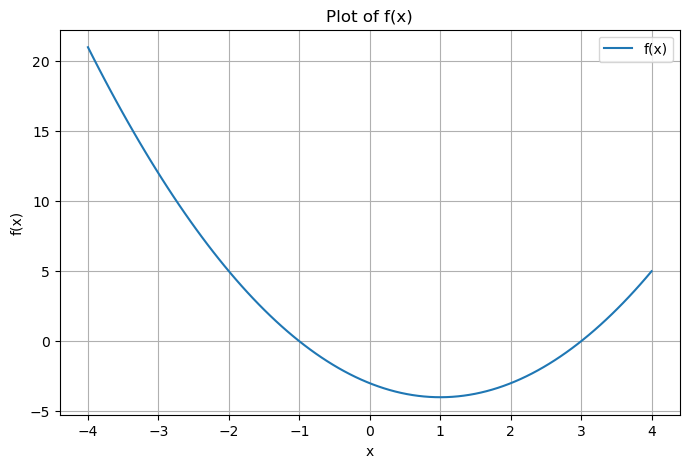

In [7]:
# Making a simple routie for plot function with simple line chart
x = np.linspace(-4, 4, 100)
y = f(x)

def plotFunc(x0, func):
    plt.figure(figsize=(8, 5))
    plt.plot(x0, func(x0), label='f(x)')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('Plot of f(x)')
    plt.grid(True)
    plt.legend()
    plt.show()
    
def plotPath(xs, ys, x0, func):
    plotFunc(x0, func)
    plt.plot(xs, ys, linestyle = '--', color = 'orange')
    plt.plot(xs[-1], ys[-1], 'ro')

In [ ]:
def GradientDescent1D(func, fprime, x0, alpha, tol = 1e-5, max_iter = 1000, verbose = False):
    # Init cur x-value (xk), f(xk), and -f'(xk)
    xk = x0
    fk = func(xk)
    pk = fprime(xk)
    
    # Initialize number of steps and lists of x- and y-coordinates
    num_iter = 1
    coord_x = [ xk ]
    coord_y = [ fk ]
    
    # Loop until the 1d gradient (derivative) is close to 0 (the error tolerance is met), or we reach max num of iters
    while ( abs(pk) > tol and num_iter < max_iter + 1 ):
        
        # Calculate new xk, f(xk), and -f'(xk)  (here is our actual gradient descent)
        xk = xk - alpha * pk
        fk = func(xk)
        pk = fprime(xk)
        
        if verbose:
            print('Iteration {}: x-cood: {}, y-coord {}, gradf(x): {}'.format(num_iter, xk, fk, pk))
            
        # Record latest coordiantes
        coord_x.append(xk)
        coord_y.append(fk)
        
        # Increment counter
        num_iter += 1
        
    # Print results to console
    if num_iter == max_iter + 1:
        print('gradient descent does not converge')
    else:
        print('Solution found:\n  y = {:.4f}\n  x = {:.4f}'.format(fk, xk))
        
    # Return lists of coordinates
    return ( coord_x, coord_y )  # NOTE: GOOD ENGINEERING HAS ONLY ONE RETURN POINT (security/debugging/stability)
        

In [ ]:
x0 = -0.4
xs, ys = GradientDescent1D(f, fprime, x0, alpha=0.1, verbose=True)
plotPath(xs, ys, x0, f)

## Gradient Descent in Higher Dimensions

$n$-dimensional Griewank Function.

Reviewed partial derivatives

### Partial Derivatives: Essential Idea of Implementation

In practice, when using the definition $\frac{}{}$... . Went over example.

Let $f(x, y, z) = x^3 y + y^3 z - \cos(xyz)$. Try and solve the partial derivatives.